In [1]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
from keras.datasets import mnist
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

I0000 00:00:1782287014.042152    7577 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782287014.047063    7577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782287014.457045    7577 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782287015.999586    7577 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
keys = {'stop': 0, 'forward': 1, 'left': 2, 'right': 3}
# keys = {'stop': 0, 'forward': 1, 'left': 2, 'right': 3, 'no_entry': 4, 'dead_end': 5}

In [3]:
stop_images_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/stop'
turn_right_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/turnright'
turn_left_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/turnleft'
no_entry_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/noentry'
dead_end_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/deadend'

stop_images_list = os.listdir(stop_images_path)
turn_right_list = os.listdir(turn_right_path)
turn_left_list = os.listdir(turn_left_path)
no_entry_list = os.listdir(no_entry_path)
dead_end_list = os.listdir(dead_end_path)

pictures = []
ys = []

# stop data
for image_name in stop_images_list:
    img = cv2.imread(f'{stop_images_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([1.0, 0, 0, 0])
    

# turn right data
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 0, 1.0])
    

# turn left data
for image_name in turn_left_list:
    img = cv2.imread(f'{turn_left_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 1.0, 0])
    
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_180)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 1.0, 0])
    
    
# forward data
for image_name in turn_left_list:
    img = cv2.imread(f'{turn_left_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 1.0, 0, 0])
    
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 1.0, 0, 0])
    
# no entry data
# for image_name in no_entry_list:
#     img = cv2.imread(f'{no_entry_path}/{image_name}')
#     img = cv2.resize(img, (128, 128))
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     pictures.append(img)
#     ys.append([0, 0, 0, 0, 1.0, 0])
    
# # dead end data
# for image_name in dead_end_list:
#     img = cv2.imread(f'{dead_end_path}/{image_name}')
#     img = cv2.resize(img, (128, 128))
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     pictures.append(img)
#     ys.append([0, 0, 0, 0, 0, 1.0])


In [4]:
pictures = np.array(pictures)
ys = np.array(ys)

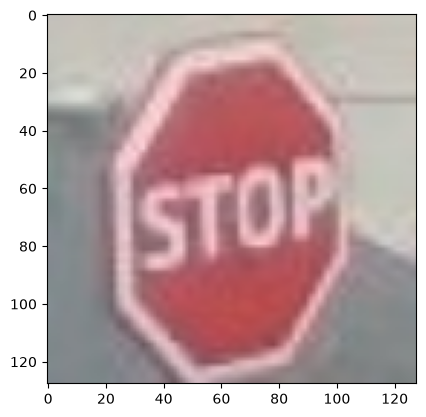

In [6]:
plt.imshow(pictures[10])

In [7]:
pictures, ys = shuffle(pictures, ys, random_state=42)

pictures = pictures.astype(np.float32) / 255.0

x_train, x_test, y_train, y_test = train_test_split(pictures, ys, test_size=0.12)

In [12]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3), padding='same'),
    MaxPool2D((2, 2)), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'), 
    MaxPool2D((2, 2)), 
    Dropout(0.25), 
    
    Conv2D(64, (3, 3), activation='relu', padding='same'), 
    MaxPool2D((2, 2)), 
    
    Flatten(), 
    
    Dense(64, activation='relu'), 
    Dropout(0.25), 
    
    Dense(4, activation='softmax')
])

In [13]:
model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])

In [14]:
model.fit(x_train ,y_train, batch_size=18, epochs=10)

Epoch 1/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.9251 - loss: 0.1807
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9962 - loss: 0.0174
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9947 - loss: 0.0154
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9976 - loss: 0.0056
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9976 - loss: 0.0055
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9962 - loss: 0.0079
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9971 - loss: 0.0084
Epoch 8/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9978 - loss: 0.0071
Epoch 9/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9990 - loss: 0.0028
Epoch 10/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9983 - loss: 0.0038


In [15]:
model.save('traffic_sign.h5')

In [17]:
num = 56

pred = list(model.predict(x_test)[num])
print(pred.index(max(pred)))
y_test[num]
# plt.imshow()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
3


array([0., 0., 0., 1.])